In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
# Path to the raw lap-level JSON file
file_path = Path("../data/lap_times_2023_3_5343.json")

# Folder for saving figures
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Top-level keys:", list(data.keys()))
print("Number of driver entries:", len(data["laps"]))

Top-level keys: ['laps', 'flags']
Number of driver entries: 36


In [3]:
rows = []

for driver_entry in data["laps"]:
    driver_name = driver_entry.get("FullName")
    car_number = driver_entry.get("Number")
    manufacturer = driver_entry.get("Manufacturer")
    driver_id = driver_entry.get("NASCARDriverID")
    
    lap_list = driver_entry.get("Laps", [])
    
    for lap_entry in lap_list:
        rows.append({
            "Driver": driver_name,
            "CarNumber": car_number,
            "Manufacturer": manufacturer,
            "NASCARDriverID": driver_id,
            "Lap": lap_entry.get("Lap"),
            "LapTime": lap_entry.get("LapTime"),
            "LapSpeed": lap_entry.get("LapSpeed"),
            "RunningPos": lap_entry.get("RunningPos")
        })

df = pd.DataFrame(rows)

print("Raw shape:", df.shape)
df.head()

Raw shape: (2575, 8)


,Driver,CarNumber,Manufacturer,NASCARDriverID,Lap,LapTime,LapSpeed,RunningPos
0,Zane Smith,38,Frd,4272,0,NaN,NaN,15
1,Zane Smith,38,Frd,4272,1,53.922,166.908,16
2,Zane Smith,38,Frd,4272,2,53.343,168.719,18
3,Zane Smith,38,Frd,4272,3,121.309,74.191,18
4,Zane Smith,38,Frd,4272,4,129.723,69.379,17


In [4]:
# Convert numeric columns
numeric_cols = ["Lap", "LapTime", "LapSpeed", "RunningPos"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with missing values in important columns
df = df.dropna(subset=["Lap", "LapTime", "LapSpeed", "RunningPos"]).copy()

# Remove Lap 0 because it is usually just initialization / pre-green data
df = df[df["Lap"] > 0].copy()

# Sort by driver and lap number
df = df.sort_values(["Driver", "Lap"]).reset_index(drop=True)

print("Shape after dropping nulls and Lap 0:", df.shape)
df.head()

Shape after dropping nulls and Lap 0: (2538, 8)


,Driver,CarNumber,Manufacturer,NASCARDriverID,Lap,LapTime,LapSpeed,RunningPos
0,Ben Rhodes,99,Frd,4107,1,53.211,169.138,19
1,Ben Rhodes,99,Frd,4107,2,52.852,170.287,17
2,Ben Rhodes,99,Frd,4107,3,120.811,74.497,17
3,Ben Rhodes,99,Frd,4107,4,129.698,69.392,16
4,Ben Rhodes,99,Frd,4107,5,131.222,68.586,17


In [5]:
# Examine the rough ranges before filtering
print(df[["LapTime", "LapSpeed", "RunningPos"]].describe())

           LapTime     LapSpeed   RunningPos
count  2538.000000  2538.000000  2538.000000
mean    144.086657   119.915525    16.739953
std     407.347106    55.729127     9.569330
min      47.199000     2.336000     1.000000
25%      49.177500    69.990250     9.000000
50%      97.437500    92.368000    17.000000
75%     128.588750   183.010250    25.000000
max    3853.200000   190.682000    36.000000


In [6]:
# Remove abnormal non-racing laps
# These thresholds are chosen to remove very slow caution/pit-influenced laps
# while keeping normal green-flag racing laps.

df_model = df[
    (df["LapTime"] < 100) &
    (df["LapSpeed"] > 100)
].copy()

print("Shape after removing abnormal/caution-like laps:", df_model.shape)
print("\nRemaining data summary:")
print(df_model[["LapTime", "LapSpeed", "RunningPos"]].describe())

Shape after removing abnormal/caution-like laps: (1248, 8)

Remaining data summary:
           LapTime     LapSpeed   RunningPos
count  1248.000000  1248.000000  1248.000000
mean     53.195099   173.095089    17.009615
std       9.509581    22.102258     9.687246
min      47.199000   100.162000     1.000000
25%      48.407000   171.712250     9.000000
50%      49.060500   183.447000    17.000000
75%      52.413250   185.924000    25.000000
max      89.854000   190.682000    36.000000


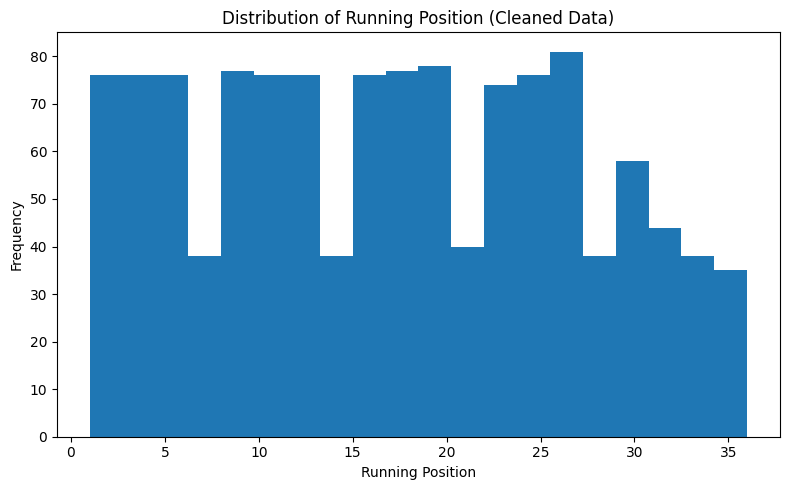

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df_model["RunningPos"], bins=20)
plt.xlabel("Running Position")
plt.ylabel("Frequency")
plt.title("Distribution of Running Position (Cleaned Data)")
plt.tight_layout()
plt.savefig(figures_dir / "running_position_distribution.png", dpi=300)
plt.show()

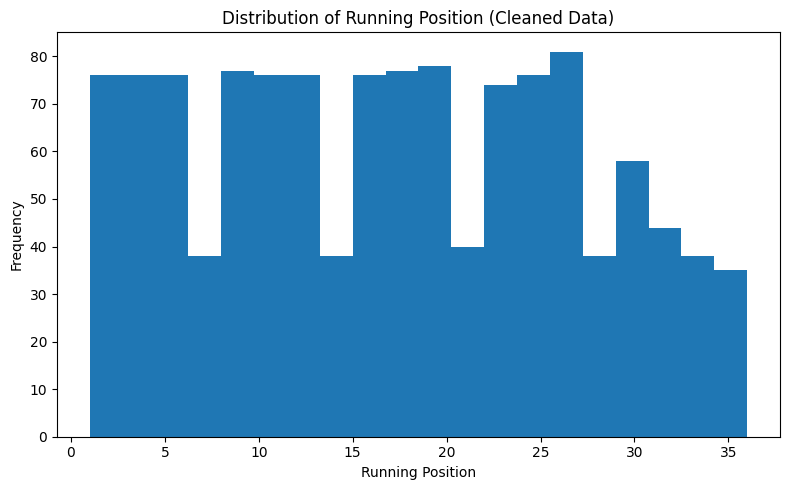

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df_model["RunningPos"], bins=20)
plt.xlabel("Running Position")
plt.ylabel("Frequency")
plt.title("Distribution of Running Position (Cleaned Data)")
plt.tight_layout()
plt.savefig(figures_dir / "running_position_distribution.png", dpi=300)
plt.show()

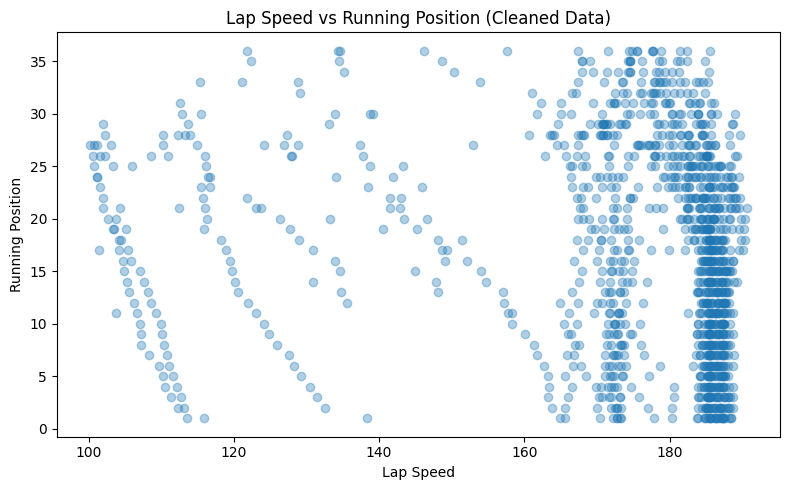

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df_model["LapSpeed"], df_model["RunningPos"], alpha=0.35)
plt.xlabel("Lap Speed")
plt.ylabel("Running Position")
plt.title("Lap Speed vs Running Position (Cleaned Data)")
plt.tight_layout()
plt.savefig(figures_dir / "lap_speed_vs_running_position_cleaned.png", dpi=300)
plt.show()

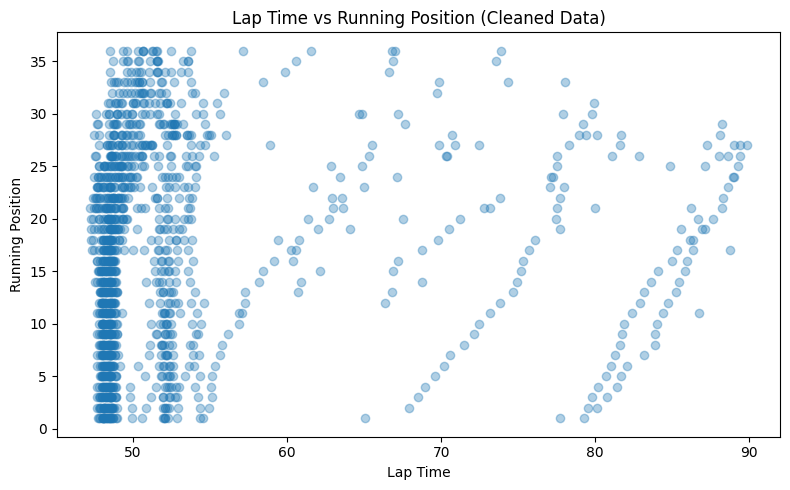

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df_model["LapTime"], df_model["RunningPos"], alpha=0.35)
plt.xlabel("Lap Time")
plt.ylabel("Running Position")
plt.title("Lap Time vs Running Position (Cleaned Data)")
plt.tight_layout()
plt.savefig(figures_dir / "lap_time_vs_running_position_cleaned.png", dpi=300)
plt.show()

In [11]:
# Baseline model setup based on Checkpoint 1:
# Target = Running Position
# Predictors = Lap Number, Lap Time, Lap Speed

X = df_model[["Lap", "LapTime", "LapSpeed"]]
y = df_model["RunningPos"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1248, 3)
y shape: (1248,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 998
Testing rows: 250


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

Intercept: 176.0064967143514
Coefficients:
  Lap: -0.0537
  LapTime: -1.1668
  LapSpeed: -0.5510


In [14]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Training Metrics")
print(f"R^2:  {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE:  {train_mae:.4f}")

print("\nTesting Metrics")
print(f"R^2:  {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")

Training Metrics
R^2:  0.0594
RMSE: 9.2628
MAE:  7.9375

Testing Metrics
R^2:  0.0350
RMSE: 9.9565
MAE:  8.7068


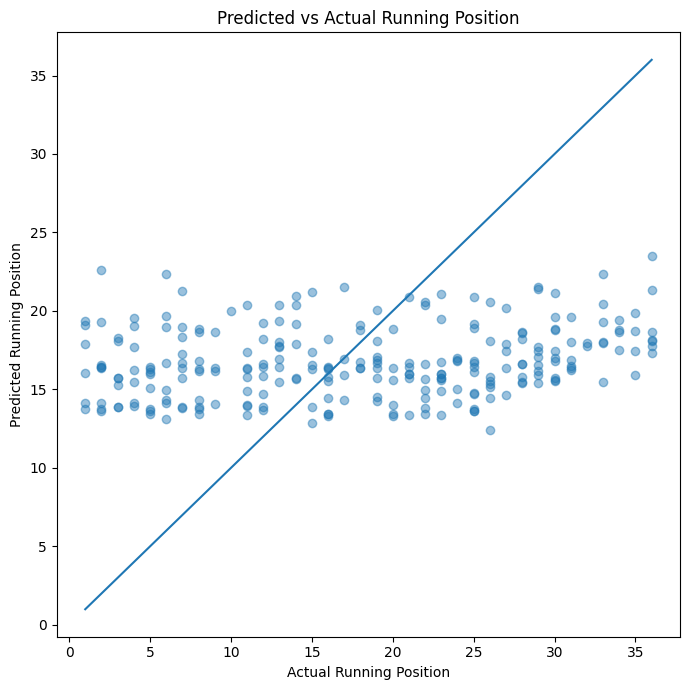

In [15]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, alpha=0.45)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Running Position")
plt.ylabel("Predicted Running Position")
plt.title("Predicted vs Actual Running Position")
plt.tight_layout()
plt.savefig(figures_dir / "predicted_vs_actual_running_position.png", dpi=300)
plt.show()

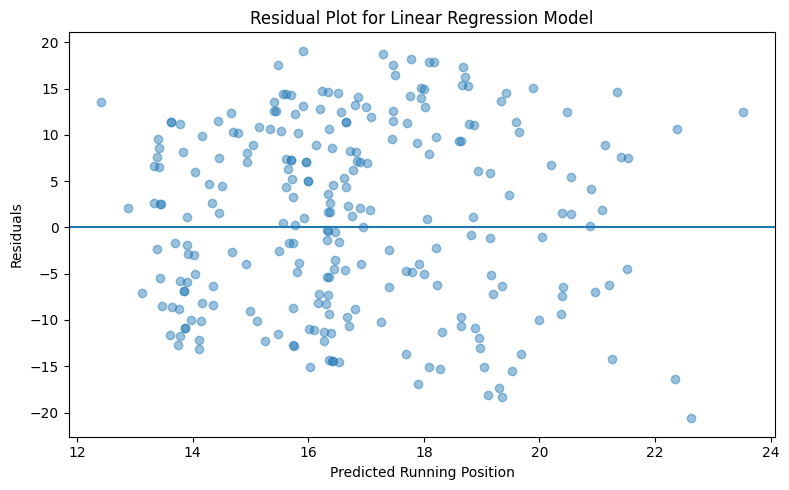

In [16]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.45)
plt.axhline(0)

plt.xlabel("Predicted Running Position")
plt.ylabel("Residuals")
plt.title("Residual Plot for Linear Regression Model")
plt.tight_layout()
plt.savefig(figures_dir / "residual_plot_linear_regression.png", dpi=300)
plt.show()

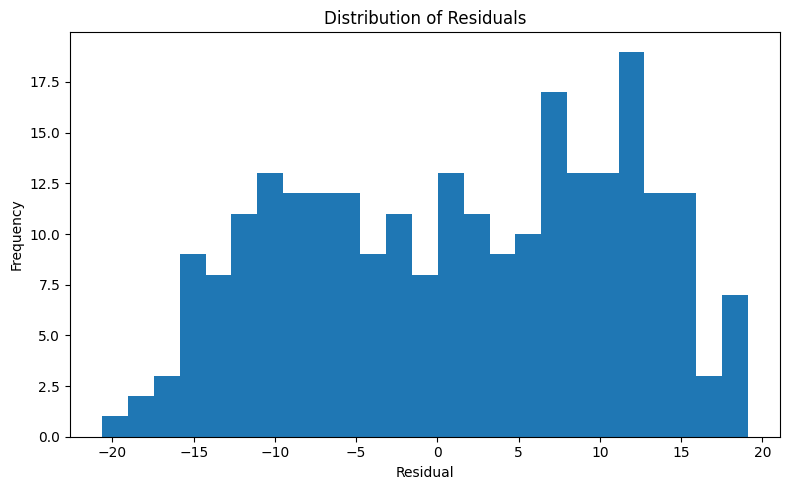

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.savefig(figures_dir / "residual_histogram.png", dpi=300)
plt.show()

In [18]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=np.abs, ascending=False)

coef_df

,Feature,Coefficient
1,LapTime,-1.166764
2,LapSpeed,-0.550963
0,Lap,-0.053661


In [19]:
print("Baseline Model Summary")
print("-" * 40)
print("Model: Linear Regression")
print("Target variable: RunningPos")
print("Predictors:", list(X.columns))
print(f"Rows used after cleaning: {len(df_model)}")
print(f"Train R^2: {train_r2:.4f}")
print(f"Test R^2: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Baseline Model Summary
----------------------------------------
Model: Linear Regression
Target variable: RunningPos
Predictors: ['Lap', 'LapTime', 'LapSpeed']
Rows used after cleaning: 1248
Train R^2: 0.0594
Test R^2: 0.0350
Train RMSE: 9.2628
Test RMSE: 9.9565
Train MAE: 7.9375
Test MAE: 8.7068


In [20]:
import sys
print(sys.executable)

c:\Users\Trenton\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
print("Imports worked")

Imports worked
